# Guía de Ejercicios 2 — Inteligencia Artificial

## Modelos gráficos probabilísticos con PyMC

Sergio Hernández — `shernandez@ucm.cl` — Universidad Católica del Maule

---


In [ ]:
# Instalación (descomentar la primera vez)
# !pip install pymc networkx pandas matplotlib

import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import networkx as nx

SEMILLA = 42
print("PyMC", pm.__version__)

PyMC 6.3.1


---
## 0. Caja de herramientas

Cuatro funciones bastan para toda la guía: simular, estimar, comparar contra la
teoría y chequear independencia.


> Ejecute la celda y siga adelante; no es necesario leerla en detalle la primera
> vez.

In [ ]:
def muestrear(modelo, n=50_000, semilla=SEMILLA):
    # Simula n casos del modelo generativo (muestreo directo, sin MCMC).
    with modelo:
        previa = pm.sample_prior_predictive(draws=n, random_seed=semilla)
    nombres = ([v.name for v in modelo.free_RVs]
               + [d.name for d in modelo.deterministics])
    return pd.DataFrame({v: previa.prior[v].values.reshape(-1) for v in nombres})


def _mascara(df, condicion):
    m = pd.Series(True, index=df.index)
    for var, val in (condicion or {}).items():
        m &= df[var] == val
    return m


def p(df, evento, dado=None):
    # Estimacion Monte Carlo de P(evento | dado).
    # Devuelve (estimacion, error_estandar, n_casos_utilizados).
    base = _mascara(df, dado)
    n = int(base.sum())
    if n == 0:
        return np.nan, np.nan, 0
    est = float((base & _mascara(df, evento)).sum()) / n
    # Piso de varianza 1/n: si no ocurre ningun caso la varianza binomial es
    # cero y el error estandar quedaria nulo, lo que hace explotar cualquier
    # cociente. El piso es la correccion de continuidad habitual.
    se = np.sqrt(max(est * (1 - est), 1.0 / n) / n)
    return est, se, n


def comparar(nombre, teorico, estimacion, umbral=4.0):
    # Contrasta un valor teorico con su estimacion Monte Carlo.
    # El criterio es la distancia en errores estandar, no la diferencia bruta:
    # con n grande se exige mas precision que con n chico.
    est, se, n = estimacion
    z = abs(est - teorico) / se if se and se > 0 else np.inf
    marca = "OK      " if z < umbral else "REVISAR "
    print(f"[{marca}] {nombre:<26s} teoria {teorico:7.4f}   "
          f"MC {est:7.4f} +/- {2 * se:.4f}   n={n:>6d}   z={min(z, 999):5.1f}")
    return z < umbral


def independencia_mc(df, X, Y, Z=(), umbral=4.0, n_min=200):
    # Contrasta P(x,y|z) = P(x|z)P(y|z) en la muestra.
    # Devuelve (compatible_con_independencia, maxima_discrepancia_estandarizada).
    # La discrepancia se mide en errores estandar: una diferencia real pero mas
    # pequena que el ruido de muestreo NO se puede detectar con esta muestra.
    X = [X] if isinstance(X, str) else list(X)
    Y = [Y] if isinstance(Y, str) else list(Y)
    Z = [Z] if isinstance(Z, str) else list(Z)
    vals = {v: sorted(df[v].unique()) for v in X + Y + Z}
    z_max = 0.0
    for zc in (itertools.product(*[vals[v] for v in Z]) if Z else [()]):
        ev = dict(zip(Z, zc))
        if int(_mascara(df, ev).sum()) < n_min:
            continue
        for xc in itertools.product(*[vals[v] for v in X]):
            ex = dict(zip(X, xc))
            px = p(df, ex, ev)[0]
            for yc in itertools.product(*[vals[v] for v in Y]):
                ey = dict(zip(Y, yc))
                py = p(df, ey, ev)[0]
                pxy, se, _ = p(df, {**ex, **ey}, ev)
                if se and se > 0:
                    z_max = max(z_max, abs(pxy - px * py) / se)
    return (z_max < umbral), min(z_max, 999.0)


def tabla_2x2(df, A="A", B="B"):
    # Tabla 2x2 con marginales, en el formato del enunciado
    lineas = [f"{'':4s} {B:>8s} {B + chr(39):>8s} {'Marginal':>9s}"]
    for etiqueta, a in [(f"{A} ", 1), (f"{A}'", 0)]:
        pb = p(df, {A: a, B: 1})[0]
        pnb = p(df, {A: a, B: 0})[0]
        lineas.append(f"{etiqueta:4s} {pb:8.4f} {pnb:8.4f} {pb + pnb:9.4f}")
    cb = p(df, {B: 1})[0]
    cnb = p(df, {B: 0})[0]
    lineas.append(f"{'Marg':4s} {cb:8.4f} {cnb:8.4f} {cb + cnb:9.4f}")
    return "\n".join(lineas)


def d_separado(aristas, X, Y, Z=()):
    # Criterio GRAFICO (Bayes-Ball). No depende de los numeros de las CPT.
    g = nx.DiGraph(aristas)
    conv = lambda s: {s} if isinstance(s, str) else set(s)
    return nx.is_d_separator(g, conv(X), conv(Y), conv(Z))


def camino_activo(aristas, X, Y, Z=()):
    # Equivalente a BayesianModel.is_active_trail de pgmpy
    return not d_separado(aristas, X, Y, Z)


def cpt(tabla):
    # Tabla de probabilidad condicional indexable por los valores de los padres
    return pt.as_tensor(np.asarray(tabla, dtype="float64"))


def check(nombre, condicion, pista=""):
    print(f"[{'OK      ' if condicion else 'REVISAR '}] {nombre}"
          + (f"   -> {pista}" if (not condicion and pista) else ""))
    return bool(condicion)


print("Herramientas cargadas.")

Herramientas cargadas.


---

 En esta sección los números salen de **datos reales**: el registro oficial de
*desvinculación escolar* del Ministerio de Educación de Chile, 2010–2024.

> **Fuente.** Centro de Estudios MINEDUC, *Tasa de incidencia de la
> desvinculación del sistema escolar*, `data/OFICIAL-Tasa-Incidencia-Desvinculacion-2010-2024.xlsx`,
> hoja «Tasas a nivel de Dependencia». La hoja apila tres tablas con el mismo
> formato: total (Tabla 1), mujeres (Tabla 1.a) y hombres (Tabla 1.b).

Un estudiante está **desvinculado** en el año $t$ si estaba matriculado en $t$
y no aparece en la matrícula de $t+1$, sin haber egresado ni fallecido. La
*tasa de incidencia* es esa cuenta dividida por la matrícula teórica.

Trabajaremos con cuatro variables:

| Variable | Valores |
|---|---|
| `COVID` | 1 = año de pandemia (2020–2021), 0 = el resto |
| `Sexo` | Mujer, Hombre |
| `Dep` | Municipal, Particular subvencionado, Particular pagado, C. Adm. delegada, Servicio Local de Educación |
| `D` | 1 = se desvincula, 0 = permanece |

El año calendario **no** entra al modelo como variable: los quince años se
colapsan en un indicador binario de pandemia. Esa decisión es cómoda —una
variable de dos estados en vez de quince— y tiene un costo que el Ejercicio 11
cobra al contado.

La pregunta que da nombre a la sección **no** es «¿qué tasa tienen los
municipales?» — eso se lee en la tabla. Es:

> ¿Cuál sería la tasa de desvinculación **si** el sistema completo pasara a una
> dependencia dada?

Es decir $P(D = 1 \mid do(\texttt{Dep} = d))$, no $P(D = 1 \mid \texttt{Dep} = d)$.
Son distintas, y la sección trata de cuánto y por qué.

In [ ]:
from pathlib import Path

HOJA = "Tasas a nivel de Dependencia"
DEPS = ["Municipal", "Particular subvencionado", "Particular pagado",
        "C. Adm. delegada", "Servicio Local de educación"]
SEXOS = ["Mujer", "Hombre"]
ANIOS = list(range(2010, 2025))
SIGLAS = {"Municipal": "MUN", "Particular subvencionado": "PSUB",
          "Particular pagado": "PPAG", "C. Adm. delegada": "CAD",
          "Servicio Local de educación": "SLEP"}


def ruta_datos(nombre="OFICIAL-Tasa-Incidencia-Desvinculacion-2010-2024.xlsx"):
    # El notebook vive en labs/pymc_tutorial/; el archivo en data/.
    for base in [Path("."), Path(".."), Path("../.."), Path("../../..")]:
        cand = base / "data" / nombre
        if cand.exists():
            return cand
    raise FileNotFoundError(f"No se encontro data/{nombre}")


def _fila_titulo(hoja, patron):
    col = hoja.iloc[:, 0].astype(str)
    return int(col[col.str.contains(patron, case=False, na=False)].index[0])


def cargar_desvinculacion(ruta=None):
    # Devuelve la tabla en formato largo: una fila por (sexo, dependencia, anio).
    hoja = pd.read_excel(ruta or ruta_datos(), sheet_name=HOJA, header=None)
    # Cada sub-tabla tiene 4 filas de encabezado antes de los datos, y por cada
    # anio un bloque de 6 columnas: Global(desv, matricula, tasa) y luego lo
    # mismo restringido al sistema regular. Nos quedamos con las columnas Global.
    primera = {"Mujer":  _fila_titulo(hoja, r"^Tabla 1\.a") + 4,
               "Hombre": _fila_titulo(hoja, r"^Tabla 1\.b") + 4}
    filas = []
    for sexo, base in primera.items():
        for i, dep in enumerate(DEPS):
            etiqueta = str(hoja.iat[base + i, 0]).split(" /")[0].strip()
            assert etiqueta == dep, f"fila {base + i}: {etiqueta!r} != {dep!r}"
            for j, anio in enumerate(ANIOS):
                c = 1 + 6 * j
                desv, matricula = hoja.iat[base + i, c], hoja.iat[base + i, c + 1]
                if pd.isna(desv) or pd.isna(matricula):
                    continue          # el SLEP no existe antes de 2018
                filas.append({"sexo": sexo, "dep": dep, "anio": int(anio),
                              "desvinculados": int(desv),
                              "matricula": int(matricula)})
    tabla = pd.DataFrame(filas)
    tabla["tasa"] = tabla.desvinculados / tabla.matricula
    return tabla


datos = cargar_desvinculacion()
print(f"{len(datos)} celdas   "
      f"{datos.matricula.sum():,} matriculas   "
      f"{datos.desvinculados.sum():,} desvinculaciones\n")
print(datos.head(3).to_string(index=False))

print("\nTasa por dependencia y anio (%):")
print((100 * datos.pivot_table(index="anio", columns="dep",
                               values="desvinculados", aggfunc="sum")
       / datos.pivot_table(index="anio", columns="dep",
                           values="matricula", aggfunc="sum")).round(2).to_string())

134 celdas   44,447,633 matriculas   723,762 desvinculaciones

 sexo       dep  anio  desvinculados  matricula     tasa
Mujer Municipal  2010          13644     604484 0.022571
Mujer Municipal  2011          15152     573750 0.026409
Mujer Municipal  2012          14395     554776 0.025947

Tasa por dependencia y anio (%):
dep   C. Adm. delegada  Municipal  Particular pagado  Particular subvencionado  Servicio Local de educación
anio                                                                                                       
2010              2.25       2.44               1.46                      1.53                          NaN
2011              3.70       2.96               2.82                      1.64                          NaN
2012              3.40       2.85               1.60                      1.55                          NaN
2013              3.21       2.61               1.79                      1.38                          NaN
2014              2.99     

Dos hechos de esa tabla mandan sobre todo lo que sigue:

1. **La pandemia rompe la serie.** La tasa baja de forma sostenida entre 2011 y
   2018, pero en **2020** se desploma a 0,93 % —durante la pandemia casi no
   hubo desvinculación registrada, porque la matrícula se congeló— y en 2021
   todavía no vuelve a la tendencia. Los años 2020–2021 no son un año más: son
   un régimen distinto. Eso es lo que codifica `COVID`.
2. **La composición del sistema también cambia.** La matrícula municipal cae de
   1,25 millones a 0,70 millones, y desde 2018 aparece el **Servicio Local de
   Educación** (SLEP), que absorbe parte de esa matrícula. El SLEP pesa 2,2 %
   de la matrícula fuera de la pandemia y 4,8 % dentro de ella.

Es decir: `COVID` afecta a la tasa **y** afecta a la dependencia. Ese es el
patrón de una **causa común**, la estructura de la sección 2.

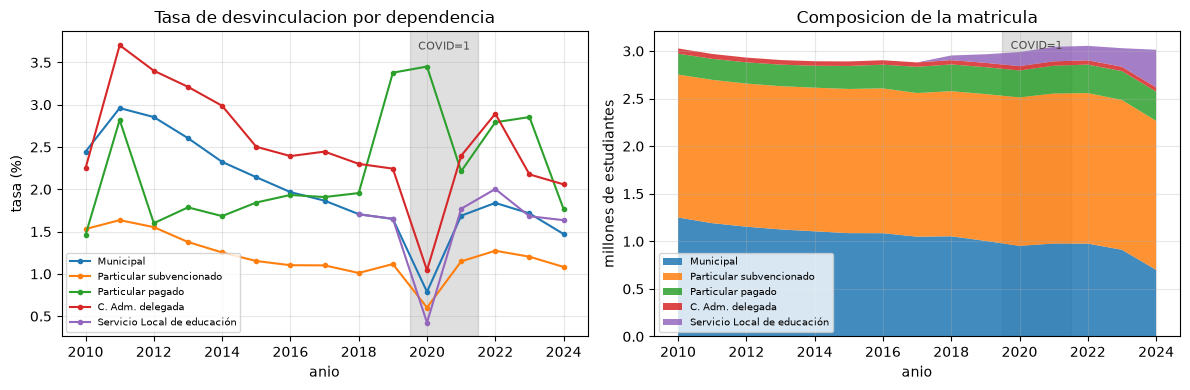

In [30]:
ANIOS_COVID = [2020, 2021]          # anios escolares afectados por la pandemia

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pivote = (datos.pivot_table(index="anio", columns="dep", values="desvinculados",
                            aggfunc="sum")
          / datos.pivot_table(index="anio", columns="dep", values="matricula",
                              aggfunc="sum"))
for dep in DEPS:
    axes[0].plot(pivote.index, 100 * pivote[dep], "o-", ms=3, label=dep)
axes[0].set_title("Tasa de desvinculacion por dependencia")
axes[0].set_xlabel("anio"); axes[0].set_ylabel("tasa (%)")
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

matricula = datos.pivot_table(index="anio", columns="dep", values="matricula",
                              aggfunc="sum").fillna(0)
axes[1].stackplot(matricula.index, *(matricula[d] / 1e6 for d in DEPS),
                  labels=DEPS, alpha=0.85)
axes[1].set_title("Composicion de la matricula")
axes[1].set_xlabel("anio"); axes[1].set_ylabel("millones de estudiantes")
axes[1].legend(fontsize=7, loc="lower left"); axes[1].grid(alpha=0.3)

# La franja marca COVID=1: el unico rasgo del anio que el modelo va a conservar.
for ax in axes:
    ax.axvspan(min(ANIOS_COVID) - 0.5, max(ANIOS_COVID) + 0.5,
               color="0.5", alpha=0.25, zorder=0)
    ax.text(np.mean(ANIOS_COVID), ax.get_ylim()[1] * 0.97, "COVID=1",
            ha="center", va="top", fontsize=8, color="0.3")

plt.tight_layout(); plt.show()

## 5.1 De la tabla al modelo generativo

La tabla da directamente todas las probabilidades condicionales que necesitamos.
Primero se **agregan** los quince años en los dos estratos de `COVID`: si
$M_{asd}$ es la matrícula de la celda del año $a$,

$$M_{csd} = \sum_{a \,:\, \texttt{COVID}(a) = c} M_{asd},
\qquad \text{y lo mismo para los desvinculados.}$$

Sumar conteos es legítimo porque la matrícula son personas: la tasa del estrato
es el **cociente de las sumas**, no el promedio de las tasas anuales. Con eso,

$$P(\texttt{COVID}=c) = \frac{M_{c}}{M}, \qquad
P(\texttt{Sexo}=s \mid c) = \frac{M_{cs}}{M_{c}}, \qquad
P(\texttt{Dep}=d \mid c, s) = \frac{M_{csd}}{M_{cs}}$$

$$P(D = 1 \mid c, s, d) = \frac{\text{desvinculados}_{csd}}{M_{csd}}$$

La última es la **tasa de incidencia** de la tabla, agregada por régimen:
condicionar la desvinculación en sexo, dependencia y pandemia es leer un bloque
de celdas y dividir.

In [31]:
COVIDS = [0, 1]
nC, nS, nD = len(COVIDS), len(SEXOS), len(DEPS)
idx_sexo = {s: i for i, s in enumerate(SEXOS)}
idx_dep = {d: i for i, d in enumerate(DEPS)}


def es_covid(anio):
    return int(anio in ANIOS_COVID)


def agregar(anios=ANIOS):
    # Colapsa los anios de `anios` en los dos estratos de COVID.
    # Devuelve (matricula, desvinculados) con forma (COVID, Sexo, Dep).
    seleccion = set(anios)
    M = np.zeros((nC, nS, nD))
    DV = np.zeros((nC, nS, nD))
    for r in datos.itertuples():
        if r.anio not in seleccion:
            continue
        c, j, k = es_covid(r.anio), idx_sexo[r.sexo], idx_dep[r.dep]
        M[c, j, k] += r.matricula
        DV[c, j, k] += r.desvinculados
    return M, DV


MATRICULA, DESVINC = agregar()

# Celdas con matricula. Ojo: aqui EXISTE es verdadero para las 20 celdas,
# incluido el SLEP, porque el estrato COVID=0 mezcla anios en que existia con
# anios en que no. Volveremos sobre eso en el Ejercicio 11.
EXISTE = MATRICULA > 0

TASA = np.divide(DESVINC, MATRICULA, out=np.zeros_like(MATRICULA), where=EXISTE)
P_COVID = MATRICULA.sum(axis=(1, 2)) / MATRICULA.sum()
P_SEXO = MATRICULA.sum(axis=2) / MATRICULA.sum(axis=2).sum(axis=1, keepdims=True)
P_DEP = MATRICULA / MATRICULA.sum(axis=2, keepdims=True)

print(f"P(COVID=1) = {P_COVID[1]:.4f}   ({len(ANIOS_COVID)} de {len(ANIOS)} anios)")
print(f"P(Mujer | COVID=0) = {P_SEXO[0, 0]:.4f}   "
      f"P(Mujer | COVID=1) = {P_SEXO[1, 0]:.4f}")

print("\nP(Dep | COVID, Mujer):")
for c in COVIDS:
    reparto = "  ".join(f"{SIGLAS[d]}={P_DEP[c, 0, k]:.3f}"
                        for k, d in enumerate(DEPS))
    print(f"  COVID={c}: {reparto}")

print("\nTasa de desvinculacion por celda (%):")
print(f"{'dependencia':<30}{'M c=0':>8}{'M c=1':>8}{'H c=0':>8}{'H c=1':>8}")
for k, dep in enumerate(DEPS):
    print(f"{dep:<30}" + "".join(f"{100 * TASA[c, j, k]:7.2f}%"
                                 for j in range(nS) for c in COVIDS))


def muestrear_cat(modelo, n=200_000, semilla=SEMILLA):
    # Igual que muestrear(), pero sin forzar booleanos: aqui Sexo y Dep tienen
    # mas de dos estados.
    with modelo:
        previa = pm.sample_prior_predictive(draws=n, random_seed=semilla)
    nombres = ([v.name for v in modelo.free_RVs]
               + [d.name for d in modelo.deterministics])
    return pd.DataFrame({v: previa.prior[v].values.reshape(-1) for v in nombres})

P(COVID=1) = 0.1357   (2 de 15 anios)
P(Mujer | COVID=0) = 0.4901   P(Mujer | COVID=1) = 0.4873

P(Dep | COVID, Mujer):
  COVID=0: MUN=0.348  PSUB=0.528  PPAG=0.088  CAD=0.014  SLEP=0.022
  COVID=1: MUN=0.312  PSUB=0.530  PPAG=0.097  CAD=0.012  SLEP=0.048

Tasa de desvinculacion por celda (%):
dependencia                      M c=0   M c=1   H c=0   H c=1
Municipal                        1.94%   1.05%   2.37%   1.42%
Particular subvencionado         1.16%   0.79%   1.35%   0.96%
Particular pagado                2.08%   2.77%   2.26%   2.88%
C. Adm. delegada                 2.69%   1.40%   2.65%   1.93%
Servicio Local de educación      1.57%   0.94%   1.84%   1.25%


---
## Ejercicio 9 — El modelo generativo

Declare en PyMC el modelo que simula **un estudiante** del sistema escolar
chileno 2010–2024:

$$P(c, s, d, D) = P(c)\,P(s \mid c)\,P(d \mid c, s)\,P(D \mid c, s, d)$$

Los cuatro tensores del paso anterior son exactamente esas cuatro CPT. `COVID`
es binaria, así que va con `pm.Bernoulli`; `Sexo` y `Dep` tienen más de dos
estados y van con `pm.Categorical`. Recuerde que en PyMC se indexa un tensor con
las variables ya declaradas: `pt.as_tensor(P_SEXO)[Covid]` devuelve el vector de
dos probabilidades correspondiente al estrato simulado.

**Complete las cuatro líneas.** El orden importa: cada variable sólo puede usar
las anteriores.

In [32]:
with pm.Model() as m_escolar:
    Covid = pm.Bernoulli("COVID", P_COVID[1])
    Sexo = pm.Categorical("Sexo", p=pt.as_tensor(P_SEXO)[Covid])
    Dep = pm.Categorical("Dep", p=pt.as_tensor(P_DEP)[Covid, Sexo])
    D = pm.Bernoulli("D", pt.as_tensor(TASA)[Covid, Sexo, Dep])

mc_escolar = muestrear_cat(m_escolar)
ARISTAS_ESCOLAR = [("COVID", "Sexo"), ("COVID", "Dep"), ("Sexo", "Dep"),
                   ("COVID", "D"), ("Sexo", "D"), ("Dep", "D")]

Sampling: [COVID, D, Dep, Sexo]


In [33]:
# Verificacion: la muestra tiene que reproducir la tabla del MINEDUC.
global_teorico = datos.desvinculados.sum() / datos.matricula.sum()
comparar("P(D=1) global", global_teorico, p(mc_escolar, {"D": 1}))

print()
for c in COVIDS:
    sub = datos[datos.anio.isin(ANIOS_COVID) == bool(c)]
    comparar(f"P(D=1 | COVID={c})",
             sub.desvinculados.sum() / sub.matricula.sum(),
             p(mc_escolar, {"D": 1}, {"COVID": c}))

print()
for k, dep in enumerate(DEPS):
    sub = datos[datos.dep == dep]
    comparar(f"P(D=1 | {dep[:18]})",
             sub.desvinculados.sum() / sub.matricula.sum(),
             p(mc_escolar, {"D": 1}, {"Dep": k}))

print()
for j, sexo in enumerate(SEXOS):
    sub = datos[datos.sexo == sexo]
    comparar(f"P(D=1 | {sexo})",
             sub.desvinculados.sum() / sub.matricula.sum(),
             p(mc_escolar, {"D": 1}, {"Sexo": j}))

print()
celda = datos[datos.anio.isin(ANIOS_COVID) & (datos.sexo == "Hombre")
              & (datos.dep == "Municipal")]
comparar("P(D=1 | COVID, H, Municipal)",
         celda.desvinculados.sum() / celda.matricula.sum(),
         p(mc_escolar, {"D": 1}, {"COVID": 1, "Sexo": 1, "Dep": 0}))

[OK      ] P(D=1) global              teoria  0.0163   MC  0.0161 +/- 0.0006   n=200000   z=  0.5

[OK      ] P(D=1 | COVID=0)           teoria  0.0170   MC  0.0167 +/- 0.0006   n=172945   z=  0.7
[OK      ] P(D=1 | COVID=1)           teoria  0.0120   MC  0.0123 +/- 0.0013   n= 27055   z=  0.5

[OK      ] P(D=1 | Municipal)         teoria  0.0205   MC  0.0202 +/- 0.0011   n= 70039   z=  0.6
[OK      ] P(D=1 | Particular subvenc) teoria  0.0121   MC  0.0118 +/- 0.0007   n=103954   z=  0.7
[OK      ] P(D=1 | Particular pagado) teoria  0.0227   MC  0.0231 +/- 0.0023   n= 17605   z=  0.4
[OK      ] P(D=1 | C. Adm. delegada)  teoria  0.0255   MC  0.0275 +/- 0.0058   n=  3168   z=  0.7
[OK      ] P(D=1 | Servicio Local de ) teoria  0.0156   MC  0.0170 +/- 0.0036   n=  5234   z=  0.8

[OK      ] P(D=1 | Mujer)             teoria  0.0148   MC  0.0151 +/- 0.0008   n= 98282   z=  0.7
[OK      ] P(D=1 | Hombre)            teoria  0.0177   MC  0.0171 +/- 0.0008   n=101718   z=  1.3

[OK      ] P(D

np.True_

## 5.2 El grafo, y por qué hay confusión

El modelo que acaba de declarar tiene este DAG:

```
       COVID ────────┐
         │  \        │
         │   \       ▼
         │    ──► Dep ──► D
         │        ▲       ▲
         ▼        │       │
        Sexo ─────┴───────┘
```

Para la pregunta «¿qué pasa si intervengo la dependencia?», el camino que
interesa es el directo $\texttt{Dep} \to D$. Pero existe además

$$\texttt{Dep} \leftarrow \texttt{COVID} \to D$$

que es una **causa común** (sección 2.2): la pandemia empuja a la vez la
composición del sistema y la tasa. Ese camino de puerta trasera (*backdoor*)
contamina el contraste observacional. Lo mismo con
$\texttt{Dep} \leftarrow \texttt{Sexo} \to D$.

Concretamente: durante la pandemia la tasa se desploma en casi todas las
dependencias —salvo en los particulares pagados, que suben— y al mismo tiempo el
SLEP pesa el doble de la matrícula. Comparar tasas crudas mezcla las dos cosas.

In [34]:
# El criterio grafico confirma la lectura: hay camino activo entre Dep y D
# aunque no se pase por la arista directa, y {COVID, Sexo} lo bloquea.
sin_directa = [a for a in ARISTAS_ESCOLAR if a != ("Dep", "D")]

print("Camino Dep - D con la arista directa borrada:")
print(f"  sin condicionar        -> activo: "
      f"{camino_activo(sin_directa, 'Dep', 'D')}")
print(f"  condicionando en COVID -> activo: "
      f"{camino_activo(sin_directa, 'Dep', 'D', ['COVID'])}")
print(f"  condicionando en ambos -> activo: "
      f"{camino_activo(sin_directa, 'Dep', 'D', ['COVID', 'Sexo'])}")

check("{COVID, Sexo} bloquea toda puerta trasera Dep -> D",
      d_separado(sin_directa, "Dep", "D", ["COVID", "Sexo"]),
      "revise ARISTAS_ESCOLAR")

Camino Dep - D con la arista directa borrada:
  sin condicionar        -> activo: True
  condicionando en COVID -> activo: True
  condicionando en ambos -> activo: False
[OK      ] {COVID, Sexo} bloquea toda puerta trasera Dep -> D


True

---
## Ejercicio 10 — Ajuste por puerta trasera

Como $\{\texttt{COVID}, \texttt{Sexo}\}$ bloquea todos los caminos de puerta
trasera y ninguno de los dos es descendiente de `Dep`, el conjunto satisface el
**criterio de puerta trasera** y el efecto es identificable:

$$P(D=1 \mid do(\texttt{Dep}=d)) = \sum_{c}\sum_{s} P(D=1 \mid c, s, d)\; P(c, s)$$

Note la diferencia con el condicional observacional, que pesa con
$P(c, s \mid d)$ — la composición **de esa dependencia** — en vez de con
$P(c, s)$ — la composición **del sistema completo**:

$$P(D=1 \mid \texttt{Dep}=d) = \sum_{c}\sum_{s} P(D=1 \mid c, s, d)\; P(c, s \mid d)$$

Las mismas tasas por celda, distintos pesos. Eso es todo lo que hace el
ajuste.

**Complete `tasa_intervenida`**: es la primera fórmula, con `TASA[:, :, k]` como
$P(D=1 \mid c, s, d)$ y `P_CONJUNTA_CS` como $P(c, s)$.

In [35]:
# P(c, s): la composicion del sistema completo, sin mirar la dependencia.
P_CONJUNTA_CS = MATRICULA.sum(axis=2) / MATRICULA.sum()
print("P(c,s) suma", P_CONJUNTA_CS.sum().round(6), " forma", P_CONJUNTA_CS.shape)
print(P_CONJUNTA_CS.round(4))


def tasa_cruda(dep, anios=ANIOS):
    # P(D=1 | Dep=dep) leida de la tabla.
    sub = datos[(datos.dep == dep) & datos.anio.isin(anios)]
    return sub.desvinculados.sum() / sub.matricula.sum()

P(c,s) suma 1.0  forma (2, 2)
[[0.4236 0.4407]
 [0.0661 0.0696]]


In [36]:
def tasa_intervenida(dep, anios=ANIOS):
    # P(D=1 | do(Dep=dep)), usando solo los anios indicados.
    k = idx_dep[dep]
    M, DV = agregar(anios)
    existe = M > 0

    if not existe[:, :, k].all():
        return np.nan          # sin soporte en algun estrato: ver Ejercicio 11

    tasa = np.divide(DV, M, out=np.zeros_like(M), where=existe)
    pesos = M.sum(axis=2) / M.sum()        # P(c, s) sobre esos mismos anios

    return float((tasa[:, :, k] * pesos).sum())

In [37]:
# Verificacion: el ajuste analitico contra la simulacion de la intervencion.
# pm.do borra las aristas que entran a Dep y la fija en k: es el grafo mutilado.
print(f"{'dependencia':<30}{'cruda':>9}{'do() formula':>14}{'do() pm.do':>13}")
print("-" * 66)
for k, dep in enumerate(DEPS):
    formula = tasa_intervenida(dep)
    if np.isnan(formula):
        print(f"{dep:<30}{100 * tasa_cruda(dep):8.2f}%{'no definida':>14}"
              f"{'--':>13}")
        continue
    mc_do = muestrear_cat(pm.do(m_escolar, {"Dep": k}), n=100_000)
    print(f"{dep:<30}{100 * tasa_cruda(dep):8.2f}%{100 * formula:13.2f}%"
          f"{100 * mc_do.D.mean():12.2f}%")
    comparar(f"  do({dep[:16]})", formula, p(mc_do, {"D": 1}))

Sampling: [COVID, D, Sexo]


dependencia                       cruda  do() formula   do() pm.do
------------------------------------------------------------------


Sampling: [COVID, D, Sexo]


Municipal                         2.05%         2.04%        2.04%
[OK      ]   do(Municipal)            teoria  0.0204   MC  0.0204 +/- 0.0009   n=100000   z=  0.2


Sampling: [COVID, D, Sexo]


...

Sampling: [COVID, D, Sexo]


Particular pagado                 2.27%         2.26%        2.28%
[OK      ]   do(Particular pagad)     teoria  0.0226   MC  0.0228 +/- 0.0009   n=100000   z=  0.4


Sampling: [COVID, D, Sexo]


C. Adm. delegada                  2.55%         2.54%        2.52%
[OK      ]   do(C. Adm. delegada)     teoria  0.0254   MC  0.0252 +/- 0.0010   n=100000   z=  0.4


Servicio Local de educación       1.56%         1.63%        1.65%
[OK      ]   do(Servicio Local d)     teoria  0.0163   MC  0.0165 +/- 0.0008   n=100000   z=  0.5


> **Lo que hay que saber leer aquí.** Para las cuatro dependencias que existen
> los quince años, el ajuste **casi no mueve nada** (Municipal 2,05 % → 2,04 %).
> No es un error: significa que la confusión por pandemia y sexo es débil,
> porque `COVID=1` pesa sólo el 14 % de la matrícula y la composición por sexo
> es prácticamente la misma en los dos estratos. Ajustar no siempre cambia la
> respuesta, y eso también es un resultado.
>
> El SLEP es otra historia. Fíjese en que **sí** obtuvo un número (1,63 %): la
> fórmula no protestó. Ese es exactamente el problema del ejercicio siguiente.

---
## Ejercicio 11 — Positividad: el caso del SLEP

Leída sin cuidado, la tabla dice que el **Servicio Local de Educación** tiene
una tasa de 1,56 %, contra 2,05 % de los municipales de los que heredó la
matrícula: casi un cuarto menos. Sería un argumento fuerte a favor de la
desmunicipalización. Y el ajuste por puerta trasera de la celda anterior parece
confirmarlo: 1,63 % contra 2,04 %.

El problema es que el SLEP **no existe antes de 2018**. Su tasa no es un
promedio sobre 2010–2024: es un promedio sobre 2018–2024, años en que *todas*
las dependencias bajaron.

El ajuste exige **positividad**: $P(\texttt{Dep} = d \mid c, s) > 0$ en cada
estrato del conjunto de ajuste. Con la variable `Anio` de quince estados, el
SLEP violaba la condición de forma visible —ocho años con probabilidad cero— y
la fórmula habría devuelto `nan`. Al colapsar el año en `COVID`, el estrato
`COVID=0` mezcla 2010–2017 (sin SLEP) con 2018–2019 y 2022–2024 (con SLEP), y la
probabilidad agregada sale positiva. **La violación no desapareció: se escondió
detrás de la agregación.** Ese es el riesgo de discretizar grueso un confusor.

La única comparación honesta sigue siendo sobre el soporte común.

**(a)** Complete `ANIOS_SLEP` con los años en que el SLEP tiene matrícula, y
compruebe que la positividad se ve satisfecha en el tensor agregado aunque no
lo esté año a año.
**(b)** Recalcule el ajuste **restringido a esos años** y responda si sobrevive
la ventaja del SLEP.

In [38]:
# (a) los anios en que el SLEP tiene matricula (en ambos sexos)
k_slep = idx_dep["Servicio Local de educación"]
ANIOS_SLEP = sorted(datos.loc[(datos.dep == "Servicio Local de educación")
                              & (datos.matricula > 0), "anio"].unique())

print("Lo que ve el modelo agregado:")
for c in COVIDS:
    print(f"  P(Dep=SLEP | COVID={c}, Mujer) = {P_DEP[c, 0, k_slep]:.4f}   "
          f"| Hombre = {P_DEP[c, 1, k_slep]:.4f}")

print(f"\nLo que dice la tabla: el SLEP existe en {len(ANIOS_SLEP)} de "
      f"{len(ANIOS)} anios -> {ANIOS_SLEP}")
sin_covid = [a for a in ANIOS if a not in ANIOS_COVID]
print(f"El estrato COVID=0 mezcla {len(sin_covid)} anios, y el SLEP existe solo "
      f"en {len([a for a in ANIOS_SLEP if a not in ANIOS_COVID])} de ellos.")

check("el tensor agregado declara soporte para el SLEP",
      bool(EXISTE[:, :, k_slep].all()))
check("pero anio a anio el soporte NO es completo",
      len(ANIOS_SLEP) < len(ANIOS),
      "la positividad se perdio al colapsar Anio en COVID")

Lo que ve el modelo agregado:
  P(Dep=SLEP | COVID=0, Mujer) = 0.0221   | Hombre = 0.0237
  P(Dep=SLEP | COVID=1, Mujer) = 0.0483   | Hombre = 0.0511

Lo que dice la tabla: el SLEP existe en 7 de 15 anios -> [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
El estrato COVID=0 mezcla 13 anios, y el SLEP existe solo en 5 de ellos.
[OK      ] el tensor agregado declara soporte para el SLEP
[OK      ] pero anio a anio el soporte NO es completo


True

In [39]:
# (b) La misma comparacion, sobre todos los anios y sobre el soporte comun.
print(f"{'dependencia':<30}{'cruda 2010-24':>15}{'do() 2010-24':>14}"
      f"{'do() soporte':>14}")
print("-" * 73)
for dep in DEPS:
    completo = tasa_intervenida(dep)
    comun = tasa_intervenida(dep, ANIOS_SLEP)
    txt = f"{100 * completo:13.2f}%" if not np.isnan(completo) else f"{'no def.':>14}"
    print(f"{dep:<30}{100 * tasa_cruda(dep):14.2f}%{txt}{100 * comun:13.2f}%")

slep, muni = "Servicio Local de educación", "Municipal"
print(f"\nVentaja cruda del SLEP sobre Municipal (2010-2024):        "
      f"{100 * (tasa_cruda(muni) - tasa_cruda(slep)):+.2f} pp")
print(f"Ventaja tras ajustar por COVID y Sexo (2010-2024):         "
      f"{100 * (tasa_intervenida(muni) - tasa_intervenida(slep)):+.2f} pp")
print(f"Ventaja sobre el soporte comun (2018-2024):                "
      f"{100 * (tasa_intervenida(muni, ANIOS_SLEP) - tasa_intervenida(slep, ANIOS_SLEP)):+.2f} pp")

check("la ventaja cruda del SLEP supera 0.4 pp",
      tasa_cruda(muni) - tasa_cruda(slep) > 0.004)
check("ajustar por COVID no la corrige: sigue sobre 0.3 pp",
      tasa_intervenida(muni) - tasa_intervenida(slep) > 0.003,
      "el ajuste sin positividad no arregla nada")
check("sobre el soporte comun la diferencia es menor a 0.1 pp",
      abs(tasa_intervenida(muni, ANIOS_SLEP)
          - tasa_intervenida(slep, ANIOS_SLEP)) < 0.001,
      "compare TASA[.., SLEP] contra TASA[.., Municipal] anio por anio")

dependencia                     cruda 2010-24  do() 2010-24  do() soporte
-------------------------------------------------------------------------
Municipal                               2.05%         2.04%         1.56%
Particular subvencionado                1.21%         1.21%         1.06%
Particular pagado                       2.27%         2.26%         2.62%
C. Adm. delegada                        2.55%         2.54%         2.13%
Servicio Local de educación             1.56%         1.63%         1.54%

Ventaja cruda del SLEP sobre Municipal (2010-2024):        +0.49 pp
Ventaja tras ajustar por COVID y Sexo (2010-2024):         +0.41 pp
Ventaja sobre el soporte comun (2018-2024):                +0.02 pp
[OK      ] la ventaja cruda del SLEP supera 0.4 pp
[OK      ] ajustar por COVID no la corrige: sigue sobre 0.3 pp
[OK      ] sobre el soporte comun la diferencia es menor a 0.1 pp


True

La ventaja desaparece por completo: sobre 2018–2024 el SLEP y los municipales
desvinculan a la misma tasa, dentro de una centésima de punto porcentual. Los
0,49 puntos de diferencia eran **la ventana temporal**, no la dependencia.

Es el mismo mecanismo de la sección 2.2 —la causa común— pero con dos vueltas de
tuerca:

1. **Ajustar no bastaba.** Para la mitad de los años la pregunta «¿cuál habría
   sido la tasa del SLEP?» no tiene respuesta en los datos. Ninguna fórmula de
   ajuste inventa soporte que no existe; lo único correcto es reducir la
   pregunta a donde sí lo hay.
2. **La discretización puede tapar el problema.** Con `Anio` de quince estados,
   la violación de positividad era visible y detenía el cálculo. Con `COVID`
   binario el cálculo corre sin quejarse y entrega 1,63 % — un número
   perfectamente formado y perfectamente engañoso. Colapsar un confusor en
   pocas categorías no sólo pierde precisión: puede **borrar la evidencia de que
   el efecto no era identificable**. Antes de confiar en un ajuste, verifique el
   soporte en la escala más fina que tengan los datos, no en la escala en que
   los metió al modelo.

> **Dos advertencias sobre lo que *no* se puede concluir.**
>
> 1. **`Sexo` no admite `do()`.** El contraste hombres 1,77 % / mujeres 1,48 %
>    es real y sobrevive al ajuste por pandemia y dependencia, pero no hay
>    intervención que asigne el sexo de un estudiante. Es una diferencia
>    descriptiva entre grupos, no un efecto causal: *no hay causación sin
>    manipulación*.
> 2. **Son datos agregados.** La tabla entrega celdas, no estudiantes. Un
>    contraste válido entre celdas puede no valer para individuos — la
>    **falacia ecológica**. Además `Dep` no se asigna al azar: las familias
>    eligen colegio, y el nivel socioeconómico, que no está en esta tabla,
>    empuja a la vez la elección y la desvinculación. Ese confusor no medido
>    **no** lo arregla ningún ajuste sobre las variables disponibles, así que la
>    columna `do()` de arriba vale bajo el supuesto — fuerte — de que el DAG de
>    la sección 5.2 está completo.

---
## Para pensar (sin entrega)

1. **Precisión y costo.** Estime $P(T=1 \mid D=1, S=0)$ con muestras de 10 mil,
   100 mil y un millón de casos. Grafique el intervalo de $\pm 2$ errores
   estándar contra el tamaño de muestra. ¿Cuántos casos necesita para distinguir
   ese valor de $P(T=1 \mid D=1, S=1)$?

2. **Valor diagnóstico.** ¿Qué examen conviene pedir primero si se sospecha
   tuberculosis: la radiografía o preguntar por el viaje? Compare cuánto cambia
   $P(T=1 \mid e)$ en cada caso, y verifique que la diferencia supera el ruido.

3. **Identificabilidad.** La cadena $A \to C \to B$ y la causa común
   $A \leftarrow C \to B$ generan exactamente las mismas independencias. Genere
   datos con una y ajuste la otra con `pm.sample`. ¿Puede distinguirlas con
   datos observacionales? ¿Qué haría falta para poder hacerlo?

4. **Cuán gruesa es demasiado.** `COVID` binario es la discretización más
   agresiva posible del año. Pruebe una intermedia —por ejemplo `Epoca` con tres
   estados: 2010–2017, 2020–2021, resto— y rehaga el Ejercicio 10. ¿Cuánto se
   mueven las tasas intervenidas? ¿En qué punto reaparece el `nan` del SLEP?

5. **Ajustar de más.** En el modelo escolar de la sección 5, ajuste el efecto de
   `Dep` sobre `D` incluyendo además el **curso** (hoja «Tasas a nivel de
   Curso»). Si la dependencia influye en el curso al que llega un estudiante,
   el curso es un *mediador*: está en el camino causal, no en la puerta trasera.
   ¿Qué le pasa al efecto estimado al condicionarlo? ¿Por qué el criterio de
   puerta trasera excluye explícitamente a los descendientes del tratamiento?